In [134]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [136]:
import pandas as pd

INPUT_DIR = "ETAPA 3 - CREACIÓN DE INDICADORES/outputs"

df_arm = pd.read_csv(f"{INPUT_DIR}/indices_manzana_armenia.csv")
df_cali = pd.read_csv(f"{INPUT_DIR}/indices_manzana_cali.csv")
df_per = pd.read_csv(f"{INPUT_DIR}/indices_manzana_pereira.csv")

print("Armenia:", df_arm.shape)
print("Cali:", df_cali.shape)
print("Pereira:", df_per.shape)

Armenia: (3190, 7)
Cali: (13617, 7)
Pereira: (3988, 7)


In [137]:
features = [
    "IND_SERVICIOS",
    "IND_EDUCACION",
    "IND_LABORAL",
    "IND_POBREZA_HAB",
    "IND_MULTIDIM"
]

In [138]:
X_arm = df_arm[features].copy()
X_cali = df_cali[features].copy()
X_per = df_per[features].copy()

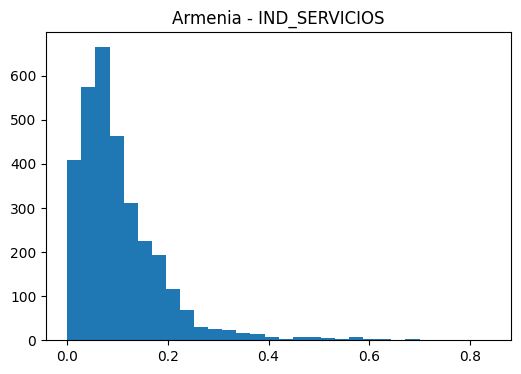

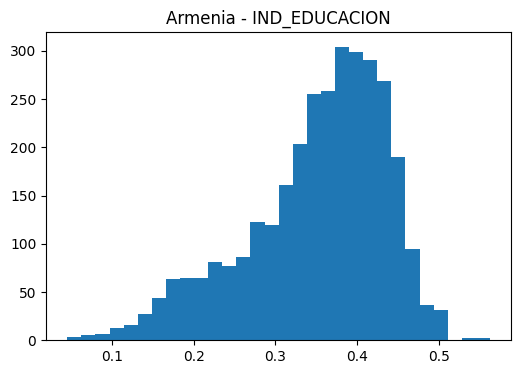

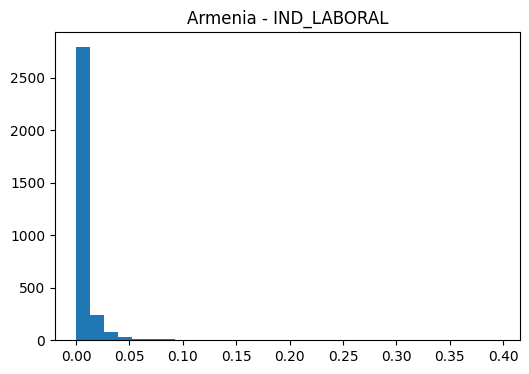

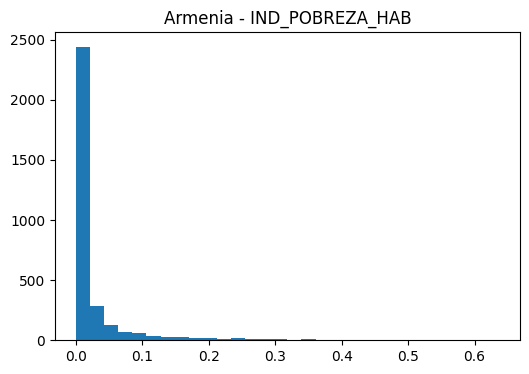

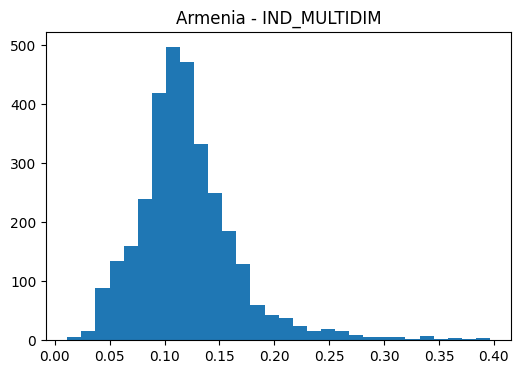

In [139]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_arm[col], bins=30)
    
    plt.title(f"Armenia - {col}")
    
    plt.show()

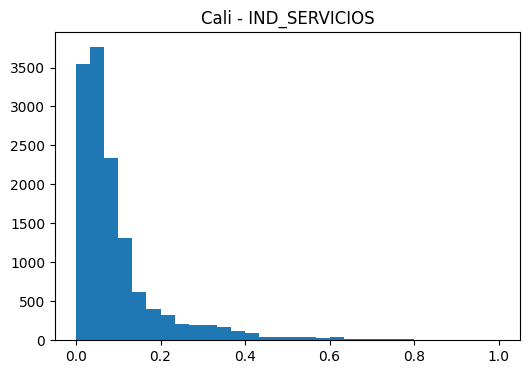

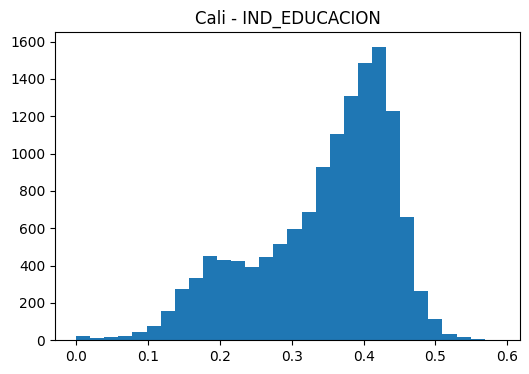

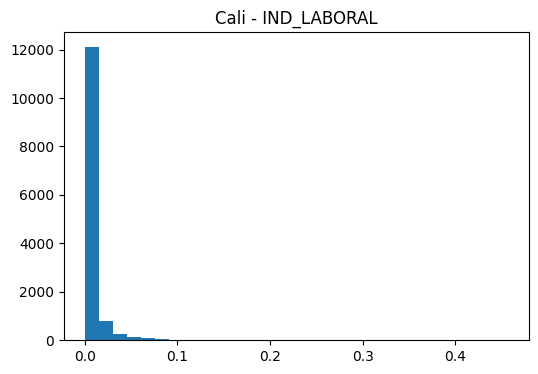

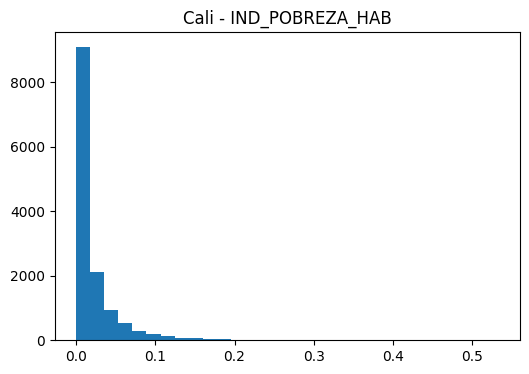

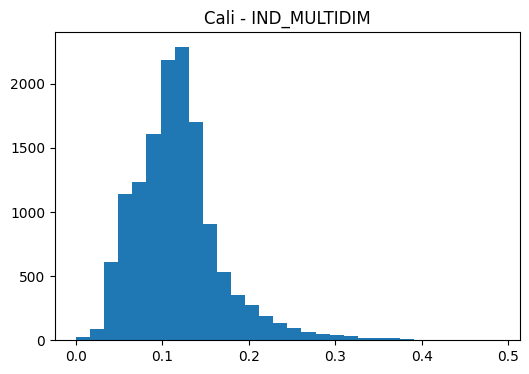

In [140]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_cali[col], bins=30)
    
    plt.title(f"Cali - {col}")
    
    plt.show()

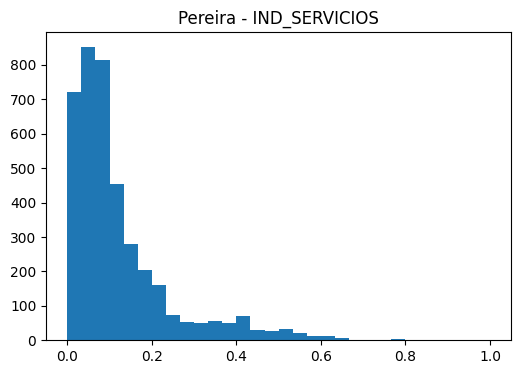

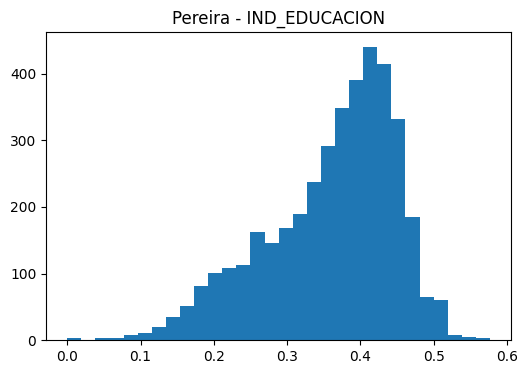

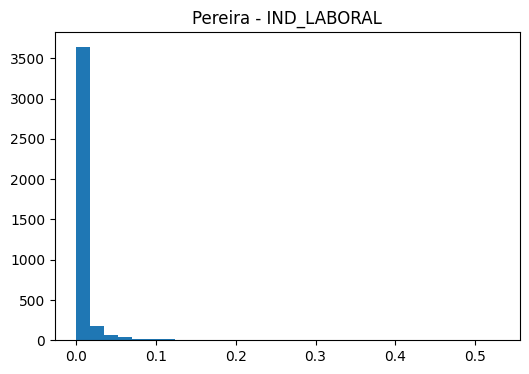

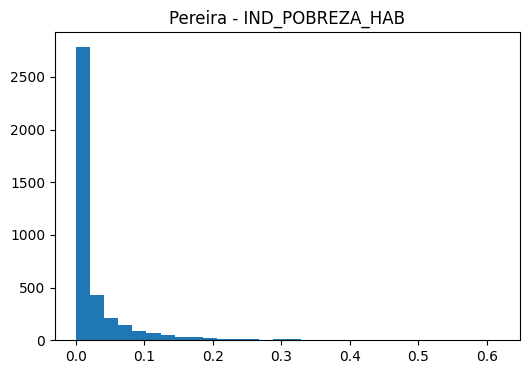

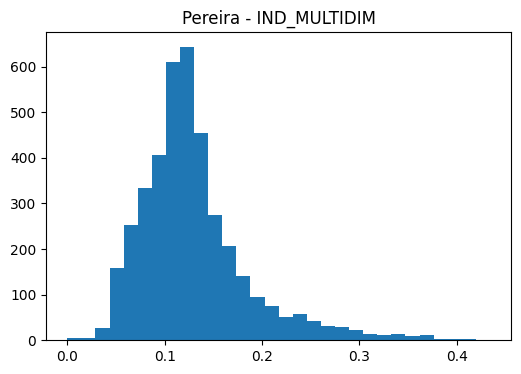

In [141]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_per[col], bins=30)
    
    plt.title(f"Pereira - {col}")
    
    plt.show()

In [142]:
scaler_arm = StandardScaler()
X_arm_scaled = scaler_arm.fit_transform(X_arm)

scaler_cali = StandardScaler()
X_cali_scaled = scaler_cali.fit_transform(X_cali)

scaler_per = StandardScaler()
X_per_scaled = scaler_per.fit_transform(X_per)

In [143]:
inertia_arm = []
K_range = range(2,10)

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X_arm_scaled)
    
    inertia_arm.append(kmeans.inertia_)

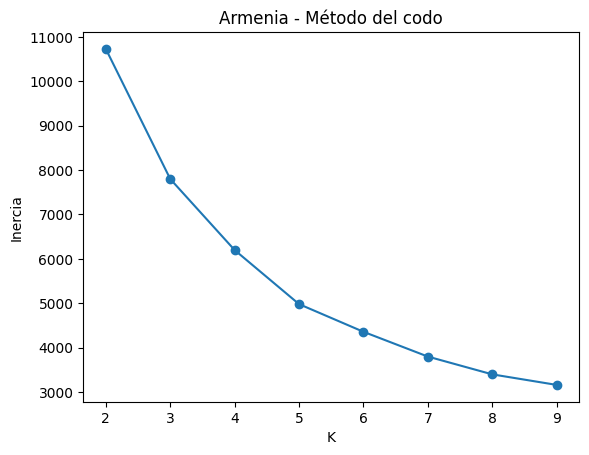

In [144]:
plt.plot(K_range, inertia_arm, marker="o")

plt.title("Armenia - Método del codo")

plt.xlabel("K")
plt.ylabel("Inercia")

plt.show()

In [145]:
sil_scores_arm = []

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(X_arm_scaled)
    
    sil = silhouette_score(X_arm_scaled, labels)
    
    sil_scores_arm.append(sil)

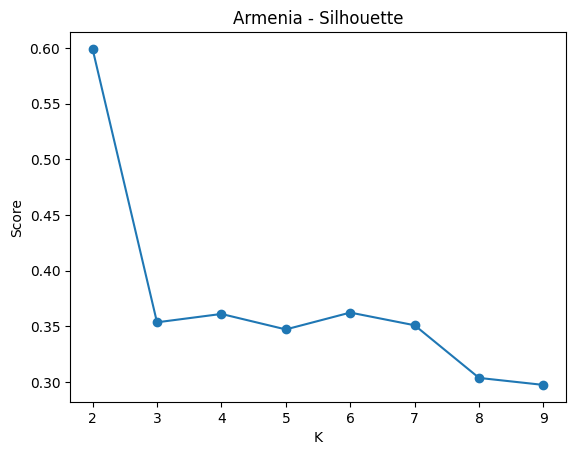

In [146]:
plt.plot(K_range, sil_scores_arm, marker="o")

plt.title("Armenia - Silhouette")

plt.xlabel("K")
plt.ylabel("Score")

plt.show()

In [147]:
kmeans_arm = KMeans(n_clusters=3, random_state=42, n_init=20)

df_arm["CLUSTER"] = kmeans_arm.fit_predict(X_arm_scaled)

In [148]:
perfil_arm = df_arm.groupby("CLUSTER")[features].mean()

perfil_arm

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
CLUSTER,,,,,
0,0.112854,0.398362,0.004550,0.016840,0.133151
1,0.335272,0.426649,0.012840,0.208530,0.245823
2,0.051292,0.262784,0.004342,0.004139,0.080639


In [149]:
df_arm["CLUSTER"].value_counts(normalize=True)

CLUSTER
0    0.574922
2    0.363950
1    0.061129
Name: proportion, dtype: float64

In [150]:
import os

OUTPUT_DIR = "ETAPA 4 - CLUSTERING/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

df_arm_export = df_arm[
    ["COD_DANE_ANM", "CLUSTER"] + features
]

df_arm_export.to_csv(
    f"{OUTPUT_DIR}/clusters_armenia.csv",
    index=False
)

print("Archivo Armenia guardado")

Archivo Armenia guardado


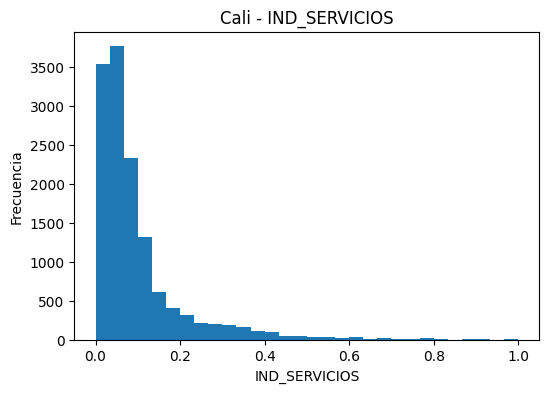

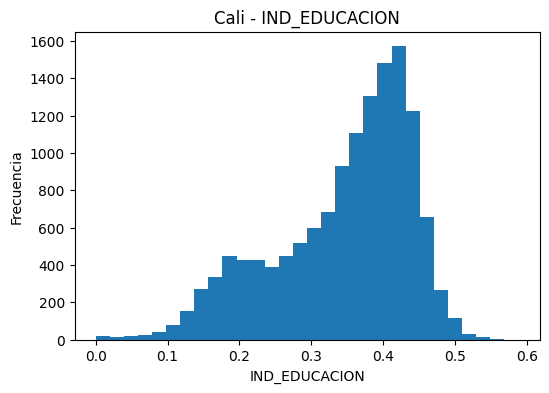

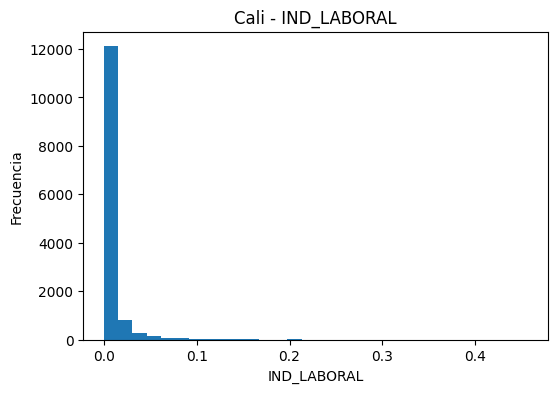

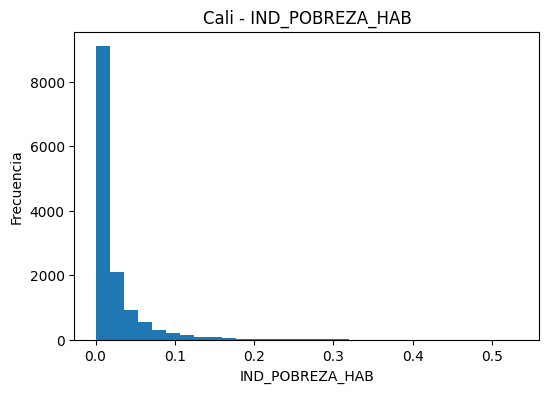

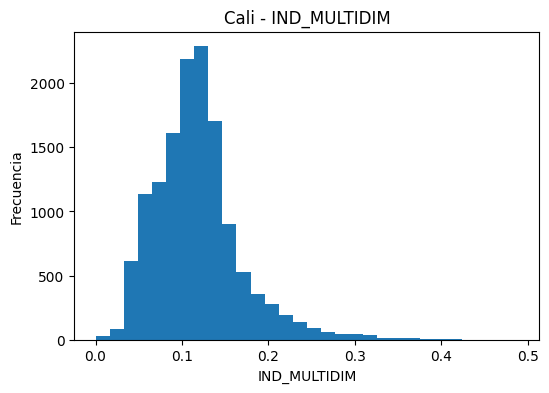

In [151]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_cali[col], bins=30)
    
    plt.title(f"Cali - {col}")
    
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    
    plt.show()

In [152]:
scaler_cali = StandardScaler()

X_cali_scaled = scaler_cali.fit_transform(X_cali)

In [153]:
inertia_cali = []

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X_cali_scaled)
    
    inertia_cali.append(kmeans.inertia_)

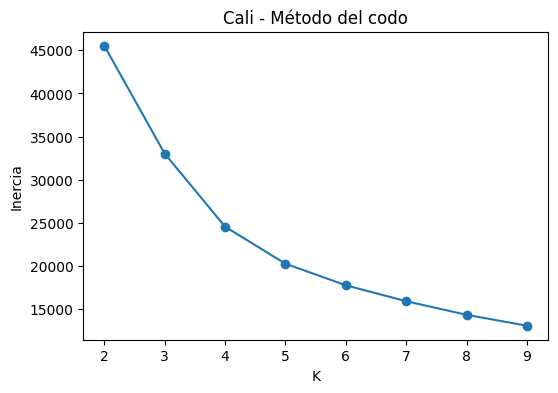

In [154]:
plt.figure(figsize=(6,4))
plt.plot(list(K_range), inertia_cali, marker="o")
plt.title("Cali - Método del codo")
plt.xlabel("K")
plt.ylabel("Inercia")
plt.xticks(list(K_range))
plt.show()

In [155]:
sil_scores_cali = []

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(X_cali_scaled)
    
    sil = silhouette_score(X_cali_scaled, labels)
    
    sil_scores_cali.append(sil)

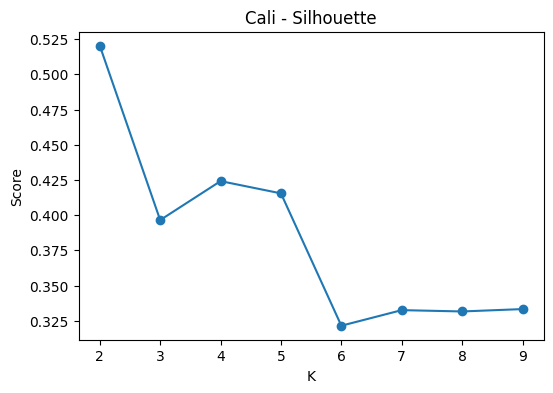

In [156]:
plt.figure(figsize=(6,4))
plt.plot(list(K_range), sil_scores_cali, marker="o")
plt.title("Cali - Silhouette")
plt.xlabel("K")
plt.ylabel("Score")
plt.xticks(list(K_range))
plt.show()

In [157]:
kmeans_cali = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df_cali["CLUSTER"] = kmeans_cali.fit_predict(X_cali_scaled)

In [158]:
perfil_cali = df_cali.groupby("CLUSTER")[features].mean()

perfil_cali

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
CLUSTER,,,,,
0,0.363691,0.430869,0.005164,0.096683,0.224102
1,0.035270,0.229162,0.004620,0.004748,0.068450
2,0.086516,0.394411,0.008145,0.017012,0.126521


In [159]:
df_cali["CLUSTER"].value_counts(normalize=True)

CLUSTER
2    0.580231
1    0.319894
0    0.099875
Name: proportion, dtype: float64

In [160]:
df_cali_export = df_cali[
    ["COD_DANE_ANM", "CLUSTER"] + features
]

df_cali_export.to_csv(
    "ETAPA 4 - CLUSTERING/outputs/clusters_cali.csv",
    index=False
)

print("Archivo Cali guardado")

Archivo Cali guardado


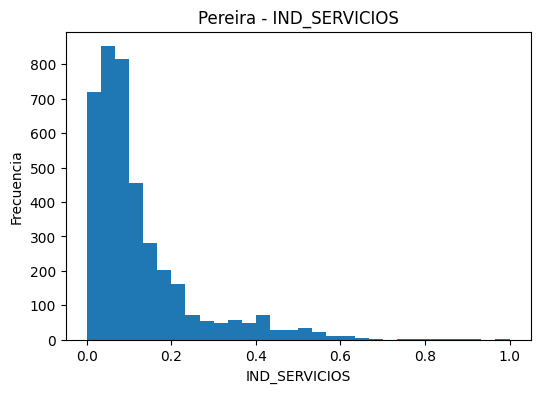

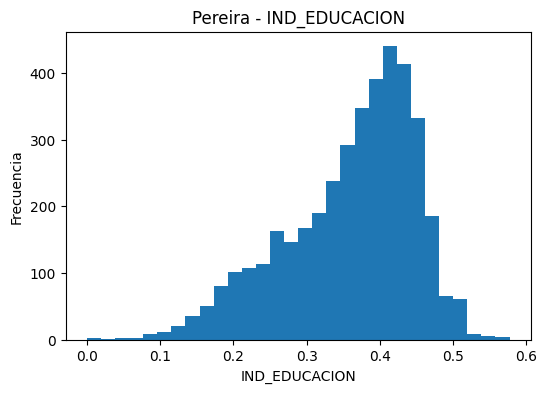

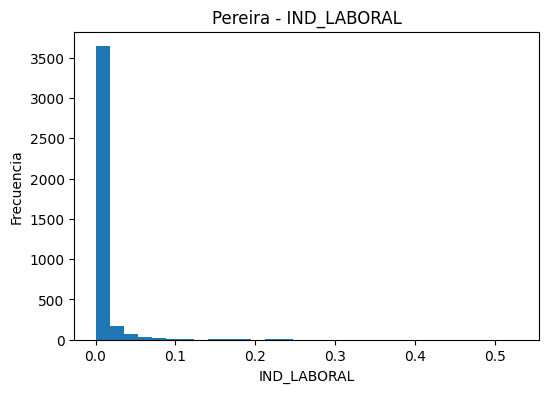

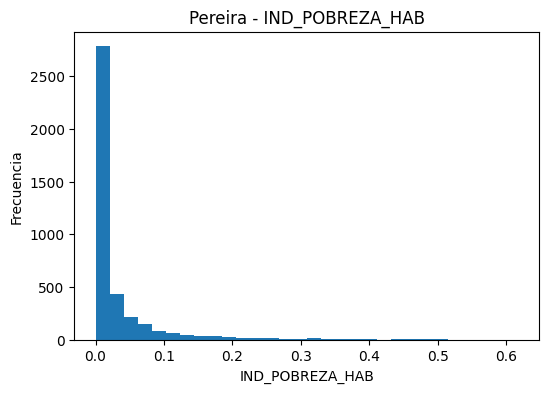

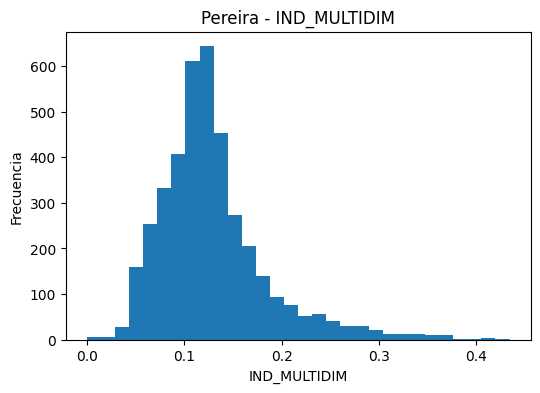

In [161]:
for col in features:
    
    plt.figure(figsize=(6,4))
    
    plt.hist(X_per[col], bins=30)
    
    plt.title(f"Pereira - {col}")
    
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    
    plt.show()

In [162]:
scaler_per = StandardScaler()

X_per_scaled = scaler_per.fit_transform(X_per)

In [163]:
K_range = range(2,10)

In [164]:
inertia_per = []

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_per_scaled)
    
    inertia_per.append(kmeans.inertia_)

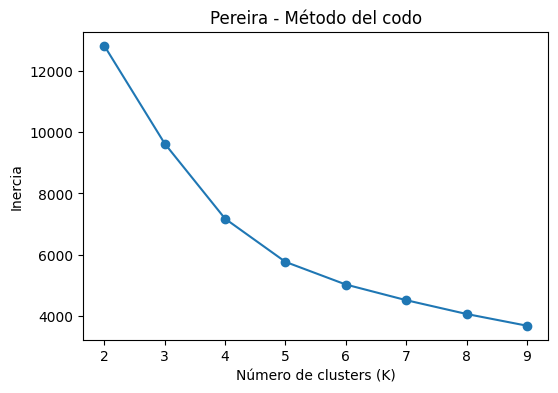

In [165]:
plt.figure(figsize=(6,4))

plt.plot(list(K_range), inertia_per, marker="o")

plt.title("Pereira - Método del codo")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")

plt.xticks(list(K_range))

plt.show()

In [166]:
sil_scores_per = []

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_per_scaled)
    
    sil = silhouette_score(X_per_scaled, labels)
    
    sil_scores_per.append(sil)

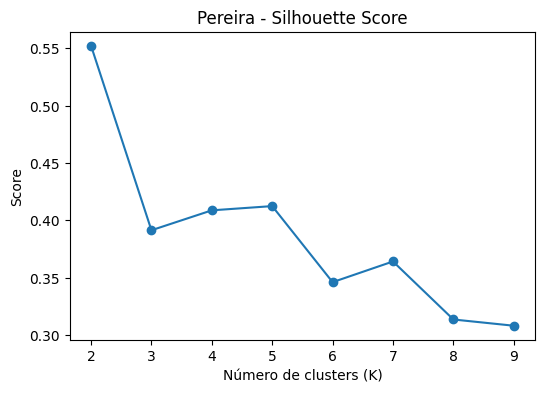

In [167]:
plt.figure(figsize=(6,4))

plt.plot(list(K_range), sil_scores_per, marker="o")

plt.title("Pereira - Silhouette Score")

plt.xlabel("Número de clusters (K)")
plt.ylabel("Score")

plt.xticks(list(K_range))

plt.show()

In [168]:
kmeans_per = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

df_per["CLUSTER"] = kmeans_per.fit_predict(X_per_scaled)

In [169]:
perfil_per = df_per.groupby("CLUSTER")[features].mean()

perfil_per

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
CLUSTER,,,,,
0,0.106361,0.402664,0.005562,0.018214,0.133200
1,0.396887,0.437201,0.011266,0.162782,0.252034
2,0.053518,0.250001,0.006355,0.005229,0.078776


In [170]:
perfil_per = df_per.groupby("CLUSTER")[features].mean()

perfil_per

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
CLUSTER,,,,,
0,0.106361,0.402664,0.005562,0.018214,0.133200
1,0.396887,0.437201,0.011266,0.162782,0.252034
2,0.053518,0.250001,0.006355,0.005229,0.078776


In [171]:
df_per_export = df_per[
    ["COD_DANE_ANM", "CLUSTER"] + features
]

df_per_export.to_csv(
    "ETAPA 4 - CLUSTERING/outputs/clusters_pereira.csv",
    index=False
)

print("Archivo Pereira guardado")

Archivo Pereira guardado


In [172]:
perfil_cali = df_cali.groupby("CLUSTER")[features].mean()
perfil_cali

,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
CLUSTER,,,,,
0,0.363691,0.430869,0.005164,0.096683,0.224102
1,0.035270,0.229162,0.004620,0.004748,0.068450
2,0.086516,0.394411,0.008145,0.017012,0.126521


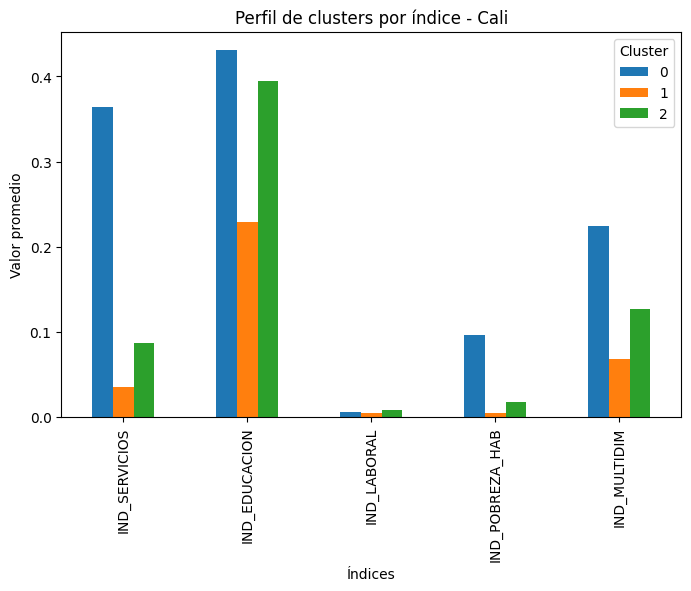

In [173]:
import matplotlib.pyplot as plt

perfil_cali.T.plot(kind="bar", figsize=(8,5))

plt.title("Perfil de clusters por índice - Cali")
plt.xlabel("Índices")
plt.ylabel("Valor promedio")

plt.legend(title="Cluster")

plt.show()

In [174]:
from pathlib import Path
import pandas as pd

base_geo = Path("ETAPA 2 - GEOREFERENCIACIÓN DE DATA/outputs")
base_cluster = Path("ETAPA 4 - CLUSTERING/outputs")
base_out = Path("ETAPA 4 - CLUSTERING/outputs")

archivos = {
    "armenia": {
        "geo": base_geo / "censo_georeferencia_armenia.csv",
        "cluster": base_cluster / "clusters_armenia.csv",
        "out": base_out / "armenia_clusters_final.csv"
    },
    "cali": {
        "geo": base_geo / "censo_georeferencia_cali.csv",
        "cluster": base_cluster / "clusters_cali.csv",
        "out": base_out / "cali_clusters_final.csv"
    },
    "pereira": {
        "geo": base_geo / "censo_georeferencia_pereira.csv",
        "cluster": base_cluster / "clusters_pereira.csv",
        "out": base_out / "pereira_clusters_final.csv"
    }
}

In [175]:
resultados_union = {}

for ciudad, rutas in archivos.items():
    print(f"\n===== {ciudad.upper()} =====")
    
    df_geo = pd.read_csv(rutas["geo"], low_memory=False)
    df_cluster = pd.read_csv(rutas["cluster"], low_memory=False)
    
    # Llave consistente
    df_geo["COD_DANE_ANM"] = df_geo["COD_DANE_ANM"].astype(str).str.strip()
    df_cluster["COD_DANE_ANM"] = df_cluster["COD_DANE_ANM"].astype(str).str.strip()
    
    # Unión
    df_final = df_geo.merge(df_cluster, on="COD_DANE_ANM", how="left")
    
    # Guardar
    df_final.to_csv(rutas["out"], index=False, encoding="utf-8-sig")
    
    print("Filas geo:", len(df_geo))
    print("Filas cluster:", len(df_cluster))
    print("Filas final:", len(df_final))
    
    if "CLUSTER" in df_final.columns:
        print("Nulos en CLUSTER:", df_final["CLUSTER"].isnull().sum())
    else:
        print("⚠️ CLUSTER no existe en el resultado")
    
    resultados_union[ciudad] = df_final


===== ARMENIA =====
Filas geo: 269280
Filas cluster: 3190
Filas final: 269280
Nulos en CLUSTER: 0

===== CALI =====
Filas geo: 1802659
Filas cluster: 13617
Filas final: 1802659
Nulos en CLUSTER: 0

===== PEREIRA =====
Filas geo: 377436
Filas cluster: 3988
Filas final: 377436
Nulos en CLUSTER: 0


In [176]:
for ciudad, df in resultados_union.items():
    print(f"\n===== {ciudad.upper()} =====")
    display(df.head(3))


===== ARMENIA =====


,COD_DANE_ANM,COD_ENCUESTAS,HA_TOT_PER,H_NRO_CUARTOS,H_NRO_DORMIT,PA1_CALIDAD_SERV,PA_ASISTENCIA,PA_LO_ATENDIERON,P_ALFABETA,P_EDADR,...,MANZ_CCDGO,DPTO_MPIO_y,GEOM_WKT,DPTO_MPIO,CLUSTER,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
0,6300110000000000010115,594972,4.0,3.0,2.0,1.0,2.0,1.0,1.0,13,...,15,63001,"POLYGON ((-75.711004 4.51884, -75.711019 4.518...",63001,0,0.103226,0.379032,0.0,0.02621,0.127117
1,6300110000000000010115,594972,4.0,3.0,2.0,NaN,2.0,NaN,1.0,13,...,15,63001,"POLYGON ((-75.711004 4.51884, -75.711019 4.518...",63001,0,0.103226,0.379032,0.0,0.02621,0.127117
2,6300110000000000010115,594972,4.0,3.0,2.0,NaN,1.0,NaN,1.0,6,...,15,63001,"POLYGON ((-75.711004 4.51884, -75.711019 4.518...",63001,0,0.103226,0.379032,0.0,0.02621,0.127117



===== CALI =====


,COD_DANE_ANM,COD_ENCUESTAS,HA_TOT_PER,H_NRO_CUARTOS,H_NRO_DORMIT,PA1_CALIDAD_SERV,PA_ASISTENCIA,PA_LO_ATENDIERON,P_ALFABETA,P_EDADR,...,MANZ_CCDGO,DPTO_MPIO_y,GEOM_WKT,DPTO_MPIO,CLUSTER,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
0,7600110000000002210101,335034,2.0,5.0,2.0,NaN,2.0,NaN,1.0,17,...,1,76001,"POLYGON ((-76.5159 3.479016, -76.515933 3.4789...",76001,1,0.040449,0.168539,0.011236,0.011236,0.057865
1,7600110000000002210101,335034,2.0,5.0,2.0,NaN,2.0,NaN,1.0,19,...,1,76001,"POLYGON ((-76.5159 3.479016, -76.515933 3.4789...",76001,1,0.040449,0.168539,0.011236,0.011236,0.057865
2,7600110000000002210106,335036,7.0,7.0,4.0,NaN,1.0,NaN,1.0,2,...,6,76001,"POLYGON ((-76.515499 3.478766, -76.515533 3.47...",76001,1,0.036538,0.182692,0.000000,0.000000,0.054808



===== PEREIRA =====


,COD_DANE_ANM,COD_ENCUESTAS,HA_TOT_PER,H_NRO_CUARTOS,H_NRO_DORMIT,PA1_CALIDAD_SERV,PA_ASISTENCIA,PA_LO_ATENDIERON,P_ALFABETA,P_EDADR,...,MANZ_CCDGO,DPTO_MPIO_y,GEOM_WKT,DPTO_MPIO,CLUSTER,IND_SERVICIOS,IND_EDUCACION,IND_LABORAL,IND_POBREZA_HAB,IND_MULTIDIM
0,6600110000000007010802,332764,4.0,5.0,3.0,NaN,2.0,NaN,1.0,9,...,2,66001,"POLYGON ((-75.704191 4.800833, -75.704246 4.80...",66001,0,0.171429,0.442509,0.003484,0.069686,0.171777
1,6600110000000007010802,332764,4.0,5.0,3.0,NaN,1.0,NaN,1.0,2,...,2,66001,"POLYGON ((-75.704191 4.800833, -75.704246 4.80...",66001,0,0.171429,0.442509,0.003484,0.069686,0.171777
2,6600110000000007010802,332764,4.0,5.0,3.0,NaN,2.0,NaN,1.0,6,...,2,66001,"POLYGON ((-75.704191 4.800833, -75.704246 4.80...",66001,0,0.171429,0.442509,0.003484,0.069686,0.171777
